# Cernere - Reconhecimento de Dígitos Manuscritos

Problema preditivo: Classificação de dígitos manuscritos (0-9) a partir de imagens.

Dataset: MNIST (Modified National Institute of Standards and Technology database), extraído da biblioteca `sklearn.datasets`.

In [1]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import keras_tuner as kt
import matplotlib.pyplot as plt
import logging
import time

from src.dataset import load_mnist_data
from src.plots import plot_digit_samples, plot_confusion_matrix
from src.preprocessing import split_data, scale_pixels
from src.models import build_knn, build_xgboost, build_hyper_mlp
from src.evaluation import evaluate_models, format_top_confusions_summary, print_classification_reports
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s', force=True)


## Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

In [3]:
# Importa o dataset MNIST via scikit-learn, fazendo uso da função definida em `src/dataset.py`. O dataset é carregado em memória e armazenado em variáveis `X` (imagens) e `y` (rótulos)
X, y = load_mnist_data()

# Verifica a dimensionalidade do dataset
print("DIMENSIONALIDADE DO DATASET:")
print(f"Formato da matriz de features (X): {X.shape}")
print(f"Formato do vetor de rótulos (y):   {y.shape}")
print(f"Tipo de dado dos pixels (X):       {X.dtype}")
print(f"Tipo de dado dos rótulos (y):      {y.dtype}")

INFO - Carregando MNIST do cache local: /Users/felipequerette/PythonProjects/mnist-digit-recognition/data/raw/mnist_784.npz
INFO - Dataset carregado com sucesso do cache local.


DIMENSIONALIDADE DO DATASET:
Formato da matriz de features (X): (70000, 784)
Formato do vetor de rótulos (y):   (70000,)
Tipo de dado dos pixels (X):       int64
Tipo de dado dos rótulos (y):      uint8


In [4]:
# Contagem e percentual de cada dígito (0 a 9)
digit_counts = pd.Series(y).value_counts().sort_index()
digit_percentages = (digit_counts / len(y)) * 100

print("DISTRIBUIÇÃO DE DÍGITOS NO DATASET:")
for digit, count, percentage in zip(digit_counts.index, digit_counts.values, digit_percentages.values):
    print(f"  Dígito {digit}: {count} ({percentage:.2f}%)")

print("-" * 30)
print(f"  Total:    {digit_counts.sum()} ({digit_percentages.sum():.2f}%)")


DISTRIBUIÇÃO DE DÍGITOS NO DATASET:
  Dígito 0: 6903 (9.86%)
  Dígito 1: 7877 (11.25%)
  Dígito 2: 6990 (9.99%)
  Dígito 3: 7141 (10.20%)
  Dígito 4: 6824 (9.75%)
  Dígito 5: 6313 (9.02%)
  Dígito 6: 6876 (9.82%)
  Dígito 7: 7293 (10.42%)
  Dígito 8: 6825 (9.75%)
  Dígito 9: 6958 (9.94%)
------------------------------
  Total:    70000 (100.00%)


INFO - Gráfico de amostras de dígitos criado com sucesso.
INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/digit_first_samples.png


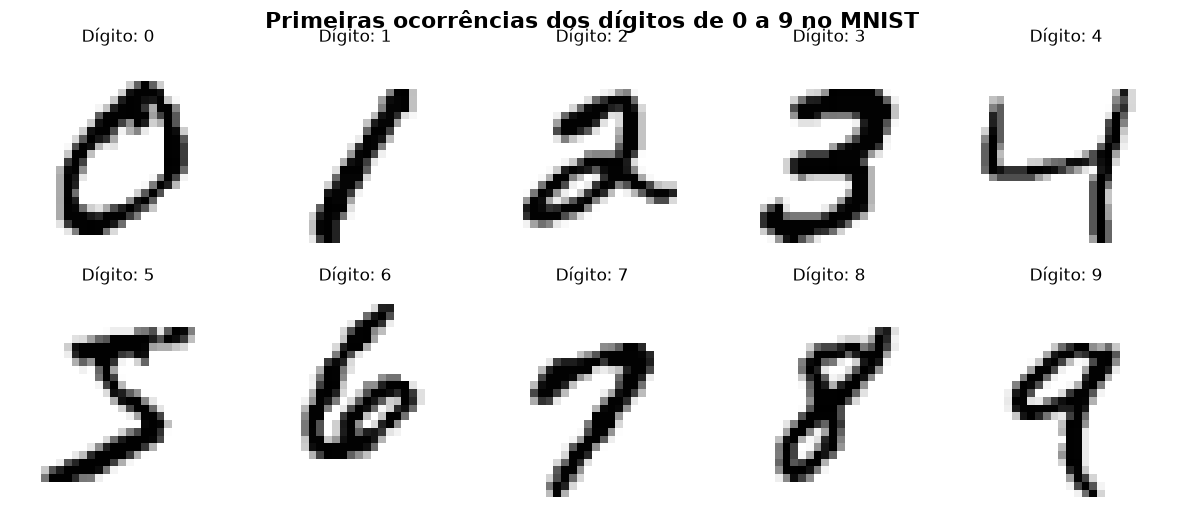

In [5]:
# Plota exemplos de imagens de cada dígito
plot_digit_samples(X, y)

### Discussão

Como vimos pela distribuição de classes, o dataset MNIST é bem equilibrado, com totais que variam entre 6.313 e 7.877 imagens por dígito.

Cada imagem é originalmente uma matriz de 28x28 pixels em escala de cinza, representando o dígito manuscrito. Cada pixel possui um valor entre 0 (preto/fundo) e 255 (branco/traço), indicando a intensidade do tom de cinza em cada ponto da imagem. Para ser utilizada na modelagem, essa matriz foi convertida em um vetor de 784 elementos (28x28), com as linhas de pixels dispostas sequencialmente. Assim, cada linha do dataset representa uma imagem de dígito manuscrito.

Embora escrevamos mais comumente com tinta escura sobre papel branco, o dataset MNIST passou por uma padronização em que os dígitos são representados com traços claros sobre fundo escuro. Isso significa que os pixels que representam o traço do dígito possuem valores mais altos (próximos de 255), enquanto os pixels do fundo possuem valores mais baixos (próximos de 0).

## Fase 2: Pré-processamento e Divisão dos Dados

In [6]:
# Divide o dataset em conjuntos de treino, validação e teste usando a função `split_data` definida em `src/preprocessing.py`. A proporção padrão, definida em `src/config.py`, é 70% para treino, 10% para validação e 20% para teste

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)


INFO - Split realizado com sucesso:
INFO -  - Treino: 48999 amostras (70.0%)
INFO -  - Validação: 7001 amostras (10.0%)
INFO -  - Teste: 14000 amostras (20.0%)


In [7]:
# Validação: confirma se a proporção das classes se manteve idêntica
split_check = pd.DataFrame({
    'Treino (%)': pd.Series(y_train).value_counts(normalize=True) * 100,
    'Validação (%)': pd.Series(y_val).value_counts(normalize=True) * 100,
    'Teste (%)': pd.Series(y_test).value_counts(normalize=True) * 100
}).sort_index()

display(split_check.round(2))

,Treino (%),Validação (%),Teste (%)
0,9.86,9.86,9.86
1,11.25,11.26,11.25
2,9.99,9.98,9.99
3,10.20,10.20,10.20
4,9.75,9.76,9.75
5,9.02,9.01,9.02
6,9.82,9.83,9.82
7,10.42,10.41,10.42
8,9.75,9.76,9.75
9,9.94,9.94,9.94


In [8]:
# Aplica a normalização dos pixels (através da divisão por 255) usando a função `scale_pixels` definida em `src/preprocessing.py`
X_train_scaled, X_val_scaled, X_test_scaled = scale_pixels(X_train, X_val, X_test)

INFO - Normalização realizada com sucesso: pixels ajustados para a escala [0.0, 1.0].


In [9]:
# Validação dos limites numéricos e tipos de dados
print(f"Treino - Mínimo: {X_train_scaled.min():.2f}, Máximo: {X_train_scaled.max():.2f}, Dtype: {X_train_scaled.dtype}")
print(f"Validação - Mínimo: {X_val_scaled.min():.2f}, Máximo: {X_val_scaled.max():.2f}, Dtype: {X_val_scaled.dtype}")
print(f"Teste - Mínimo: {X_test_scaled.min():.2f}, Máximo: {X_test_scaled.max():.2f}, Dtype: {X_test_scaled.dtype}")

Treino - Mínimo: 0.00, Máximo: 1.00, Dtype: float32
Validação - Mínimo: 0.00, Máximo: 1.00, Dtype: float32
Teste - Mínimo: 0.00, Máximo: 1.00, Dtype: float32


### Discussão

Nesta fase, foi feita a divisão do dataset em conjuntos de treino, validação e teste, utilizando a função `split_data` definida em `src/preprocessing.py`. A divisão foi realizada de forma estratificada, garantindo que a proporção de cada dígito fosse mantida em todos os conjuntos.

A normalização dos pixels foi realizada dividindo cada valor por $255.0$, convertendo os dados para o tipo `float32` no intervalo $[0.0, 1.0]$. Esta etapa é crucial para o desempenho de algoritmos de aprendizado de máquina:

- Para modelos baseados em distâncias métricas (como o KNN), a escala padronizada assegura que o cálculo da distância atribua peso equivalente a todos os pixels, evitando que atributos com maior variância numérica distorçam a similaridade entre as imagens. Em termos práticos, embora o traço do numeral seja a informação principal, a ausência de traço (o fundo) também é fundamental para diferenciar dígitos visualmente parecidos, como o 3 e o 8.

- Para modelos lineares e algoritmos de otimização (como Regressão Logística e Gradiente Descendente), a padronização deixa a superfície de erro equilibrada. Podemos imaginar que o algoritmo está descendo uma montanha no escuro em busca do ponto mais baixo (o menor erro): se as variáveis estiverem em escalas muito diferentes, o terreno fica cheio de desfiladeiros estreitos e o modelo fica dando passos em ziguezague, demorando muito para chegar ao fundo. Com a escala padronizada entre 0 e 1, o terreno vira o fundo de uma cumbuca lisa, permitindo que o algoritmo dê passos diretos e estáveis rumo ao aprendizado mais rápido.

## Fase 3: Implementação e Treinamento dos 3 Modelos

Nesta fase, serão realizados três treinamentos: dois com modelos clássicos de classificação — o K-Nearest Neighbors (KNN), baseado em distâncias métricas, e o XGBoost, baseado em árvores sequenciais de decisão — e um utilizando uma Rede Neural.

### KNN (K-Nearest Neighbors)

In [10]:
# Treinamento com KNN

# 1. Instancia o modelo base, utilizando a função `build_knn` definida em `src/models.py`. O modelo é instanciado com os hiperparâmetros padrão (n_neighbors=5, weights='distance').
knn_base = build_knn()

# 2. Define uma grade com os 2 hiperparâmetros que serão otimizados: `n_neighbors` e `weights`.
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

# 3. Configura o GridSearch com 3-fold cross-validation
grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Executa a otimização no conjunto de treino normalizado
logging.info("Iniciando a busca de hiperparâmetros com GridSearchCV para treinamento do modelo KNN...")
start_time = time.time()
grid_search_knn.fit(X_train_scaled, y_train)
fit_time_knn = time.time() - start_time
logging.info(f"Busca concluída em {fit_time_knn:.2f} segundos.")

# 5. Exibe os melhores resultados encontrados
logging.info(f"Melhores Hiperparâmetros: {grid_search_knn.best_params_}")
logging.info(f"Melhor Acurácia (Treino CV): {grid_search_knn.best_score_ * 100:.2f}%")

# 6. Avalia o melhor modelo no conjunto de Validação
best_knn = grid_search_knn.best_estimator_
y_val_pred_knn = best_knn.predict(X_val_scaled)

INFO - Criando KNN com n_neighbors=5 e weights='distance'
INFO - Iniciando a busca de hiperparâmetros com GridSearchCV para treinamento do modelo KNN...


Fitting 3 folds for each of 8 candidates, totalling 24 fits


INFO - Busca concluída em 118.22 segundos.
INFO - Melhores Hiperparâmetros: {'n_neighbors': 3, 'weights': 'distance'}
INFO - Melhor Acurácia (Treino CV): 96.84%


### XGBoost (Extreme Gradient Boosting)

In [11]:
#Treinamento com XGBoost

# 1. Instancia o modelo base usando a função `build_xgboost` definida em `src/models.py`. O modelo é instanciado com os hiperparâmetros padrão (n_estimators=100, max_depth=3).
xgb_base = build_xgboost()

# 2. Espaço de hiperparâmetros para busca (9 combinações totais no espaço)
param_distributions_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 6, 8]
}

# 3. Configura uma busca aleatória (RandomizedSearchCV) para otimização dos hiperparâmetros do modelo XGBoost. 
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions_xgb,
    n_iter=4,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=1,
    verbose=2
)

# 4. Executa a otimização no conjunto de treino
logging.info("Iniciando o treinamento do XGBoost com RandomizedSearchCV...")
start_time = time.time()
random_search_xgb.fit(X_train_scaled, y_train)
fit_time_xgb = time.time() - start_time
logging.info(f"Treinamento do XGBoost concluído em {fit_time_xgb:.2f} segundos!")

# 5. Avaliação do melhor modelo encontrado
best_xgb = random_search_xgb.best_estimator_
y_val_pred_xgb = best_xgb.predict(X_val_scaled)

INFO - Instanciando XGBClassifier com n_estimators=100, max_depth=6, learning_rate=0.1, eval_metric=mlogloss
INFO - Iniciando o treinamento do XGBoost com RandomizedSearchCV...


Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ......................max_depth=8, n_estimators=100; total time= 1.1min
[CV] END ......................max_depth=8, n_estimators=100; total time= 1.1min
[CV] END ......................max_depth=8, n_estimators=100; total time= 1.2min
[CV] END ......................max_depth=3, n_estimators=100; total time=  23.7s
[CV] END ......................max_depth=3, n_estimators=100; total time=  23.3s
[CV] END ......................max_depth=3, n_estimators=100; total time=  22.4s
[CV] END ......................max_depth=6, n_estimators=150; total time= 1.1min
[CV] END ......................max_depth=6, n_estimators=150; total time= 1.1min
[CV] END ......................max_depth=6, n_estimators=150; total time= 1.1min
[CV] END .......................max_depth=3, n_estimators=50; total time=  11.6s
[CV] END .......................max_depth=3, n_estimators=50; total time=  11.5s
[CV] END .......................max_depth=3, n_es

INFO - Treinamento do XGBoost concluído em 598.91 segundos!


No treinamento do KNN foi utilizado o `GridSearchCV` para otimizar os hiperparâmetros `n_neighbors` e `weights`.

Já no caso do XGBoost, foi utilizado o `RandomizedSearchCV` para otimizar os hiperparâmetros `n_estimators` e `max_depth`. O `GridSearchCV` aumentou demais o tempo levando na otimização dos hiperparâmetros do XGBoost, de modo a tornar seu uso impeditivo no contexto do presente projeto. A busca aleatória, então, foi utilizada para reduzir o tempo de treinamento, uma vez que limitamos os testes a apenas 4 combinações de hiperparâmetros (através do parâmetro n_iter) em vez de todas as 9 possíveis (o que ainda assim levou mais de 10 minutos no Macbook deste desenvolvedor que lhes escreve).

### Rede Neural

In [12]:
# Configuração do Tuner usando a fábrica adaptada definida em `src/models.py`. O Tuner é configurado para realizar uma busca aleatória (RandomSearch) com 6 tentativas (trials) e 1 execução por tentativa, visando maximizar a acurácia de validação.
tuner = kt.RandomSearch(
    hypermodel=build_hyper_mlp,
    objective="val_accuracy",
    max_trials=6,
    executions_per_trial=1,
    directory="keras_tuning_logs",
    project_name="mnist_mlp",
    overwrite=True
)

logging.info("Iniciando a otimização de hiperparâmetros da Rede Neural (MLP)...")
start_time = time.time()

tuner.search(
    X_train_scaled, 
    y_train, 
    epochs=10, 
    validation_data=(X_val_scaled, y_val),
    batch_size=128,
    verbose=1
)

fit_time_mlp = time.time() - start_time
logging.info(f"Otimização concluída em {fit_time_mlp:.2f} segundos.")

# Extração e avaliação do melhor modelo
logging.info("Extraindo e avaliando o melhor modelo...")
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_mlp = tuner.get_best_models(num_models=1)[0]

y_val_pred_probs = best_mlp.predict(X_val_scaled)
y_val_pred_mlp = y_val_pred_probs.argmax(axis=1)

print("\n--- Resultados da Rede Neural (Validação) ---")
print(f"Melhor número de neurônios: {best_hps.get('units')}")
print(f"Melhor função de ativação: {best_hps.get('activation')}")
print(f"Melhor taxa de aprendizado: {best_hps.get('learning_rate')}")
print(f"Acurácia na Validação: {accuracy_score(y_val, y_val_pred_mlp) * 100:.2f}%")
print("\nRelatório de Classificação:")
print(classification_report(y_val, y_val_pred_mlp))

INFO - Otimização concluída em 64.92 segundos.


INFO - Extraindo e avaliando o melhor modelo...


Trial 6 Complete [00h 00m 09s]
val_accuracy: 0.9752892255783081

Best val_accuracy So Far: 0.9752892255783081
Total elapsed time: 00h 01m 05s


INFO - Instanciando MLP Classifier [units=128, activation=relu, lr=0.001]


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step


/Users/felipequerette/PythonProjects/mnist-digit-recognition/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(store)



--- Resultados da Rede Neural (Validação) ---
Melhor número de neurônios: 128
Melhor função de ativação: relu
Melhor taxa de aprendizado: 0.001
Acurácia na Validação: 97.53%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       690
           1       0.98      0.99      0.98       788
           2       0.97      0.99      0.98       699
           3       0.98      0.96      0.97       714
           4       0.97      0.98      0.98       683
           5       0.97      0.98      0.98       631
           6       0.98      0.99      0.98       688
           7       0.97      0.97      0.97       729
           8       0.98      0.96      0.97       683
           9       0.96      0.96      0.96       696

    accuracy                           0.98      7001
   macro avg       0.98      0.98      0.98      7001
weighted avg       0.98      0.98      0.98      7001



## Fase 4: Avaliação Comparativa de Desempenho

TABELA COMPARATIVA CONSOLIDADA (CONJUNTO DE TESTE INDEPENDENTE)


,Modelo,Acurácia Global,Precisão (Weighted),Recall (Weighted),F1-Score (Weighted),Tempo Treino (s),Tempo Inferência (s)
0,KNN,0.9721,0.9724,0.9721,0.9721,118.2184,6.6894
1,XGBoost,0.9714,0.9715,0.9714,0.9714,598.9093,0.0827
2,MLP (Keras),0.9774,0.9775,0.9774,0.9774,64.9153,0.4167



--- Classification Report Detalhado: KNN ---
              precision    recall  f1-score   support

           0     0.9752    0.9957    0.9853      1381
           1     0.9589    0.9937    0.9760      1575
           2     0.9897    0.9592    0.9742      1398
           3     0.9727    0.9713    0.9720      1428
           4     0.9842    0.9553    0.9695      1365
           5     0.9651    0.9628    0.9639      1263
           6     0.9756    0.9884    0.9819      1375
           7     0.9649    0.9794    0.9721      1459
           8     0.9870    0.9458    0.9660      1365
           9     0.9525    0.9655    0.9589      1391

    accuracy                         0.9721     14000
   macro avg     0.9726    0.9717    0.9720     14000
weighted avg     0.9724    0.9721    0.9721     14000


--- Classification Report Detalhado: XGBoost ---
              precision    recall  f1-score   support

           0     0.9778    0.9891    0.9834      1381
           1     0.9872    0.9829   

INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/confusion_matrix_knn.png


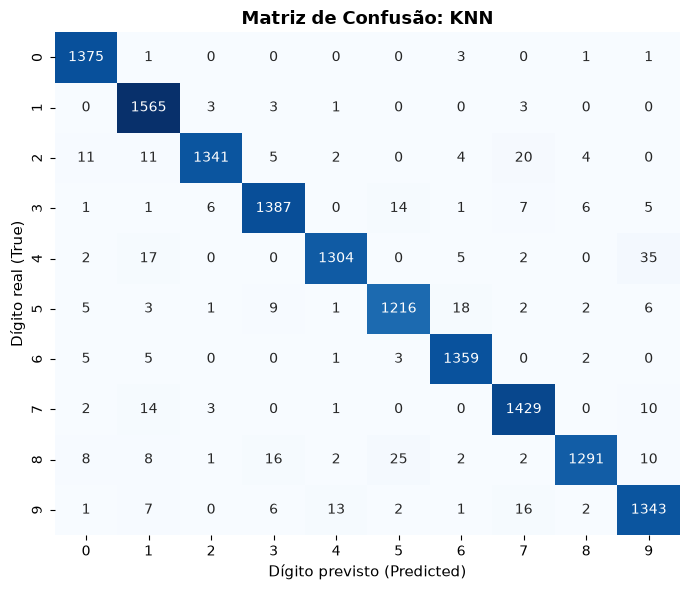

INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/confusion_matrix_xgboost.png


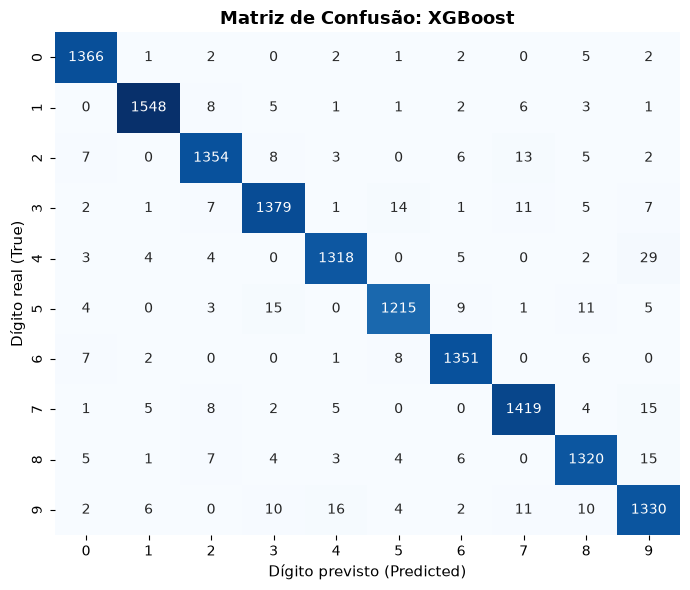

INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/confusion_matrix_mlp_keras.png


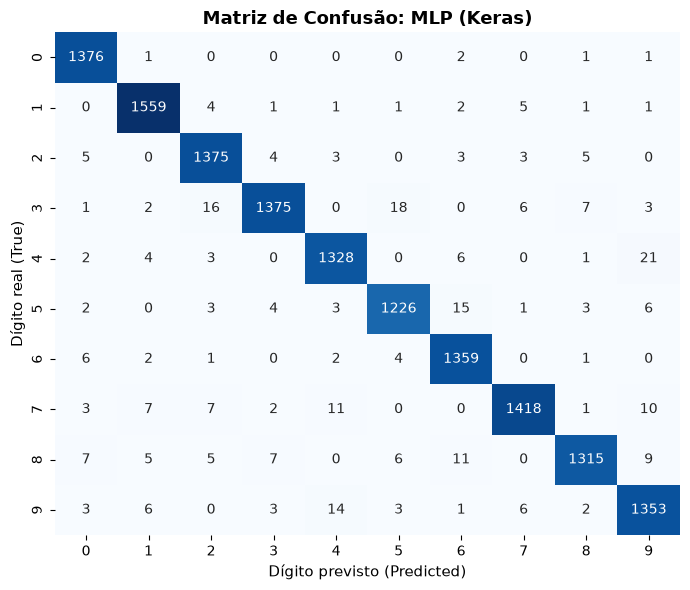


Maiores Taxas de Confusão por Modelo (Verdadeiro vs Previsto)
* KNN: Dígito 4 previsto como 9 (35x), Dígito 8 previsto como 5 (25x), Dígito 2 previsto como 7 (20x)
* XGBoost: Dígito 4 previsto como 9 (29x), Dígito 9 previsto como 4 (16x), Dígito 5 previsto como 3 (15x)
* MLP (Keras): Dígito 4 previsto como 9 (21x), Dígito 3 previsto como 5 (18x), Dígito 3 previsto como 2 (16x)


In [14]:
# Modelos treinados:
models = {
    'KNN': best_knn,
    'XGBoost': best_xgb,
    'MLP (Keras)': best_mlp
}

# Tempo de treinamento de cada modelo (em segundos)
train_times = {
    'KNN': fit_time_knn,
    'XGBoost': fit_time_xgb,
    'MLP (Keras)': fit_time_mlp
}

# Executa a avaliação dos modelos treinados no conjunto de teste, utilizando a função `evaluate_models` definida em `src/evaluation.py`
df_metrics, predictions = evaluate_models(
    models=models,
    X_test=X_test_scaled,
    y_test=y_test,
    train_times=train_times
)

# Exibe a tabela consolidada de métricas de avaliação para cada modelo
print("=" * 80)
print("TABELA COMPARATIVA CONSOLIDADA (CONJUNTO DE TESTE INDEPENDENTE)")
print("=" * 80)
display(df_metrics.round(4))

# Exibe relatórios de classificação detalhados para cada modelo, utilizando a função `print_classification_reports` definida em `src/evaluation.py`
print_classification_reports(predictions, y_test)

# Renderiza e salva as Matrizes de Confusão 10x10 empilhadas individualmente
print("\n" + "=" * 80)
print("Matrizes de confusão 10x10 (heatmaps)")
print("=" * 80)

for model_name, y_pred in predictions.items():
    plot_confusion_matrix(
        y_true=y_test,
        y_pred=y_pred,
        model_name=model_name,
        figsize=(7, 6)
    )

# Diagnóstico de Maior Confusão de Dígitos por Modelo
print("\n" + format_top_confusions_summary(predictions, y_test, top_n=3))